In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import itertools
import logging
from pathlib import Path
from typing import Any, TypeVar
import re

import h5py
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
import seaborn as sns
from tqdm.auto import tqdm

In [3]:
from src.data import add_metadata_features
from src.viz import plot_epochs, add_timit_insets, add_pod_line, add_uv_annotation

In [4]:
L = logging.getLogger(__name__)

In [5]:
sns.set_context(font_scale=1.5)

In [6]:
trf_eois = "outputs/trf_eois/eois.csv"
trf_stepwise_eois = "outputs/analyze_stepwise/eois.csv"

all_epoch_paths = list(Path("outputs/epochs_preprocessed").glob("*_epo.fif"))
epoched_phoneme_path = "/userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-all.h5"
epoched_phoneme_onset_path = "/userdata/jgauthier/projects/ideal-word-representations/phoneme_epochs-onsets.h5"
pval_threshold = 1e-3
uv_threshold = 0
outdir = "."

In [7]:
timit_epoch_sources = {
    "All": epoched_phoneme_path,
    "Word onset": epoched_phoneme_onset_path,
}

In [8]:
eoi_df = pd.read_csv(trf_eois, index_col=["subject", "electrode", "feature_block"])
eoi_df = eoi_df[eoi_df.unique_variance > uv_threshold]
eoi_df

,,,unique_variance
subject,electrode,feature_block,
EC250,215,acoustic,0.017799
EC282,84,acoustic,0.011961
EC248,382,acoustic,0.011833
EC243,102,mismatch,0.011563
EC260,204,mismatch,0.011078
...,...,...,...
EC270,137,acoustic,0.000035
EC287,124,acoustic,0.000033
EC278,90,lexical_evidence,0.000025


In [9]:
stepwise_eoi_df = pd.read_csv(trf_stepwise_eois, index_col=["subject", "electrode", "progression"])
stepwise_eoi_df = stepwise_eoi_df[stepwise_eoi_df.r2_diff > 0]

# We only care about the final step of each progression (testing gradient response)
stepwise_eoi_df = stepwise_eoi_df[stepwise_eoi_df.progression_step == 2]

stepwise_eoi_df = stepwise_eoi_df.sort_values("r2_diff", ascending=False)
stepwise_eoi_df

progression_step    r2_pre   r2_post   rss_pre  \
subject electrode progression                                                   
EC248   382       acoustic                    2  0.023749  0.025316  1.437144   
EC243   102       acoustic                    2  0.041149  0.042300  1.393199   
EC260   92        mismatch                    2  0.003214  0.004058  1.216693   
EC248   381       acoustic                    2  0.010108  0.010748  1.634071   
EC260   219       mismatch                    2  0.019379  0.019852  1.299320   
        220       mismatch                    2  0.013335  0.013784  1.362608   
EC248   381       mismatch                    2  0.008410  0.008790  1.636874   
EC253   196       mismatch                    2  0.007023  0.007318  1.434204   
EC243   102       mismatch                    2  0.040045  0.040288  1.394802   
EC279   5         acoustic                    2  0.002897  0.003076  1.404241   
EC248   364       mismatch                    2  0.001252  0.001401  1.096142   
EC279   4         mismatch                    2  0.005910  0.005995  1.258536   
EC278   27        mismatch                    2  0.012488  0.012533  1.037707   
EC279   6         mismatch                    2  0.005333  0.005378  1.341299   
EC270   137       mismatch                    2  0.000785  0.000827  0.923075   
EC260   191       acoustic                    2  0.000727  0.000759  1.462807   
        222       acoustic                    2  0.004677  0.004701  1.237459   
EC270   139       mismatch                    2  0.001060  0.001076  1.095046   
        137       acoustic                    2  0.000785  0.000795  0.923075   

                               rss_post  df_diff  df_residual  ftest_stat  \
subject electrode progression                                               
EC248   382       acoustic     1.434837      243       102465    0.677963   
EC243   102       acoustic     1.391526      243       102465    0.507073   
EC260   92        mismatch     1.215663      243       102465    0.357379   
EC248   381       acoustic     1.633015      243       102465    0.272816   
EC260   219       mismatch     1.298693      243       102465    0.203521   
        220       mismatch     1.361988      243       102465    0.191895   
EC248   381       mismatch     1.636247      243       102465    0.161433   
EC253   196       mismatch     1.433778      243       102465    0.125069   
EC243   102       mismatch     1.394449      243       102465    0.106733   
EC279   5         acoustic     1.403989      243       102465    0.075673   
EC248   364       mismatch     1.095977      243       102465    0.063106   
EC279   4         mismatch     1.258428      243       102465    0.036234   
EC278   27        mismatch     1.037660      243       137025    0.025709   
EC279   6         mismatch     1.341239      243       102465    0.018911   
EC270   137       mismatch     0.923037      243        50625    0.008699   
EC260   191       acoustic     1.462759      243       102465    0.013688   
        222       acoustic     1.237428      243       102465    0.010304   
EC270   139       mismatch     1.095029      243        50625    0.003242   
        137       acoustic     0.923066      243        50625    0.002181   

                               ftest_pval  rss_diff   r2_diff  
subject electrode progression                                  
EC248   382       acoustic       0.999967 -0.002307  0.001567  
EC243   102       acoustic       1.000000 -0.001673  0.001152  
EC260   92        mismatch       1.000000 -0.001030  0.000844  
EC248   381       acoustic       1.000000 -0.001057  0.000640  
EC260   219       mismatch       1.000000 -0.000627  0.000473  
        220       mismatch       1.000000 -0.000620  0.000449  
EC248   381       mismatch       1.000000 -0.000626  0.000379  
EC253   196       mismatch       1.000000 -0.000425  0.000294  
EC243   102       mismatch       1.000000 -0.000353  0.000243  
EC279  

In [30]:
epochs = {}
for path in tqdm(all_epoch_paths):
    subject_name = re.findall("(EC[\d]+)_epo", str(path))[0]
    epochs[subject_name] = mne.read_epochs(str(path), verbose=False)
    try:
        epochs[subject_name].metadata = add_metadata_features(epochs[subject_name].metadata)
    except AssertionError:
        del epochs[subject_name]
        continue

  0%|          | 0/10 [00:00<?, ?it/s]

Replacing existing metadata with 96 columns
Replacing existing metadata with 95 columns
Replacing existing metadata with 95 columns
Replacing existing metadata with 96 columns
Replacing existing metadata with 96 columns
Replacing existing metadata with 96 columns
Replacing existing metadata with 95 columns
Replacing existing metadata with 96 columns
Replacing existing metadata with 96 columns
Replacing existing metadata with 95 columns


## Plots

In [29]:
epoch_times = next(iter(epochs.values())).times

In [23]:
def make_epochs_df(feature_block, plot_eoi_df=None, baseline=None):
    all_plot_epochs, all_plot_epochs_df = {}, {}

    if plot_eoi_df is None:
        plot_eoi_df = eoi_df
    try:
        plot_eoi_df = plot_eoi_df.loc[(slice(None), slice(None), feature_block)]
    except KeyError:
        L.info(f"Feature block {feature_block} not found in eoi_df")
        return None, None

    epochs_ = epochs
    if baseline is not None:
        epochs_ = {subject: epochs[subject].copy().apply_baseline(baseline) for subject in epochs}

    for subject, channel in plot_eoi_df.index:
        plot_epochs = epochs_[subject]
        plot_epochs_df = plot_epochs.metadata.loc[plot_epochs.selection]
        plot_epochs_df["mismatch"] = plot_epochs_df.mismatch.map({-1: False, 1: True})
        plot_epochs_df["mismatch_left_right"] = plot_epochs_df["mismatch_left_right"].map({-1: "left", 1: "right"})
        plot_epochs_df["lexical_evidence_cue"] = plot_epochs_df["lexical_evidence_cue"].map({-1: "left", 1: "right"})
        plot_epochs_df["categorical_acoustic_cue"] = plot_epochs_df["categorical_acoustic_cue"].map({-1: "left", 1: "right"})
        plot_epochs_df["categorical_behavior"] = plot_epochs_df["behavior_categorical"].map({-1: "left", 0: "neither", 1: "right"})

        all_plot_epochs[subject, channel] = plot_epochs.get_data()[:, channel, :]
        all_plot_epochs_df[subject, channel] = plot_epochs_df

    all_plot_epochs_df = pd.concat(all_plot_epochs_df, names=["subject", "channel", "epoch_idx"])
    all_plot_epochs_df["facet_label"] = all_plot_epochs_df.index.get_level_values("subject").str.cat(
        (all_plot_epochs_df.index.get_level_values("channel") + 1).astype(str), sep="_")

    return all_plot_epochs, all_plot_epochs_df

In [24]:
plot_specs = {
    ("eoi", "lexical_evidence"): {
        "": dict(baseline=None,
                hue="lexical_evidence_cue", hue_order=["left", "right"],
                share_groupers=True),
        "-baselined": dict(baseline=(None, 0),
                        hue="lexical_evidence_cue", hue_order=["left", "right"],
                        share_groupers=True),
        "-baselined-split": dict(baseline=(None, 0), hue="label_acoustic", style="label_lexical",
                                share_groupers=False),
        "-split": dict(baseline=None, hue="label_acoustic", style="label_lexical",
                       share_groupers=False),
        "-baselined-belief_update": dict(baseline=(None, 0),
                                         hue="belief_update_int", hue_order=[-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5],
                                         palette="coolwarm",
                                         share_groupers=False),
        "-baselined-belief_update_coarse": dict(baseline=(None, 0),
                                         hue="belief_update_int_coarse", hue_order=[-5, -2, 0, 2, 5],
                                         palette="coolwarm",
                                         share_groupers=False),

        "-baselined-split-behavior": dict(baseline=(None, 0), hue="label_acoustic_emoji", style="label_behavior_emoji",
                                          share_groupers=False),
    },

    ("eoi", "acoustic"): {
        "": dict(baseline=None,
                hue="categorical_acoustic_cue", hue_order=["left", "right"],
                share_groupers=True),
        "-baselined": dict(baseline=(None, 0),
                        hue="categorical_acoustic_cue", hue_order=["left", "right"],
                        share_groupers=True),
        "-baselined-split": dict(baseline=(None, 0), hue="label_acoustic", style="label_lexical",
                                share_groupers=False),
        "-split": dict(baseline=None, hue="label_acoustic", style="label_lexical",
                       share_groupers=False),
        "-baselined-continuous": dict(baseline=(None, 0),
                                      hue="resampled", hue_order=[1, 2, 3, 4, 5, 6],
                                      palette="RdBu",
                                      share_groupers=True),

        "-baselined-split-behavior": dict(baseline=(None, 0), hue="label_acoustic_emoji", style="label_behavior_emoji",
                                          share_groupers=False),
    },

    ("eoi", "mismatch"): {
        "": dict(baseline=None,
                 hue="mismatch_left_right", hue_order=["left", "right"],
                 share_groupers=True),
        "-baselined": dict(baseline=(None, 0),
                           hue="mismatch_left_right", hue_order=["left", "right"],
                           share_groupers=True),
        "-baselined-split": dict(baseline=(None, 0), hue="label_acoustic", style="label_lexical",
                                 share_groupers=False),
        "-split": dict(baseline=None, hue="label_acoustic", style="label_lexical",
                       share_groupers=False),
        "-baselined-belief_update": dict(baseline=(None, 0),
                                         hue="belief_update_int", hue_order=[-5, -4, -3, 3, 4, 5],
                                         # NB hue order only includes belief updates which are consistent with a mismatch. other trials
                                         # will not be plotted
                                         palette="coolwarm",
                                         share_groupers=True),
        "-baselined-belief_update_coarse": dict(baseline=(None, 0),
                                         hue="belief_update_int_coarse_mismatch_only", hue_order=[-5, -2, 0, 2, 5],
                                         palette="coolwarm",
                                         share_groupers=True),

        "-baselined-split-behavior": dict(baseline=(None, 0), hue="label_acoustic_emoji", style="label_behavior_emoji",
                                          share_groupers=False),
    },

    ("stepwise_eoi", "acoustic"): {
        "-baselined-continuous": dict(baseline=(None, 0),
                                      hue="resampled", hue_order=[1, 2, 3, 4, 5, 6],
                                      palette="coolwarm",
                                      share_groupers=True),
    },

    ("stepwise_eoi", "mismatch"): {
        "-baselined-belief_update": dict(baseline=(None, 0),
                                         hue="belief_update_int", hue_order=[-5, -4, -3, 3, 4, 5],
                                         # NB hue order only includes belief updates which are consistent with a mismatch. other trials
                                         # will not be plotted
                                         palette="coolwarm",
                                         share_groupers=True),
    },
}

In [25]:
ep_df.groupby("label").label_behavior.value_counts()

label  label_behavior
b→b    b                 97
       p                 36
       m                 10
       ~                  1
b→m    b                 59
       m                 13
b→p    p                 62
       b                  9
       ~                  1
d→d    d                 62
       n                 10
d→n    d                 47
       n                 25
m→b    m                 40
       b                 32
m→m    m                 51
       b                 21
n→d    n                 63
       d                  9
n→n    n                 63
       d                  8
       ~                  1
p→b    p                 55
       b                 17
p→p    p                 70
       b                  2
Name: count, dtype: int64

In [26]:
ep_df.label

subject  channel  epoch_idx
EC243    103      0            p→b
                  1            n→d
                  2            p→b
                  3            b→b
                  4            b→b
                              ... 
                  859          m→m
                  860          b→p
                  861          p→b
                  862          p→p
                  863          d→n
Name: label, Length: 864, dtype: object

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


yerp, no epochs for EC243 103 label_lexical d n
yerp, no epochs for EC243 103 label_lexical n d


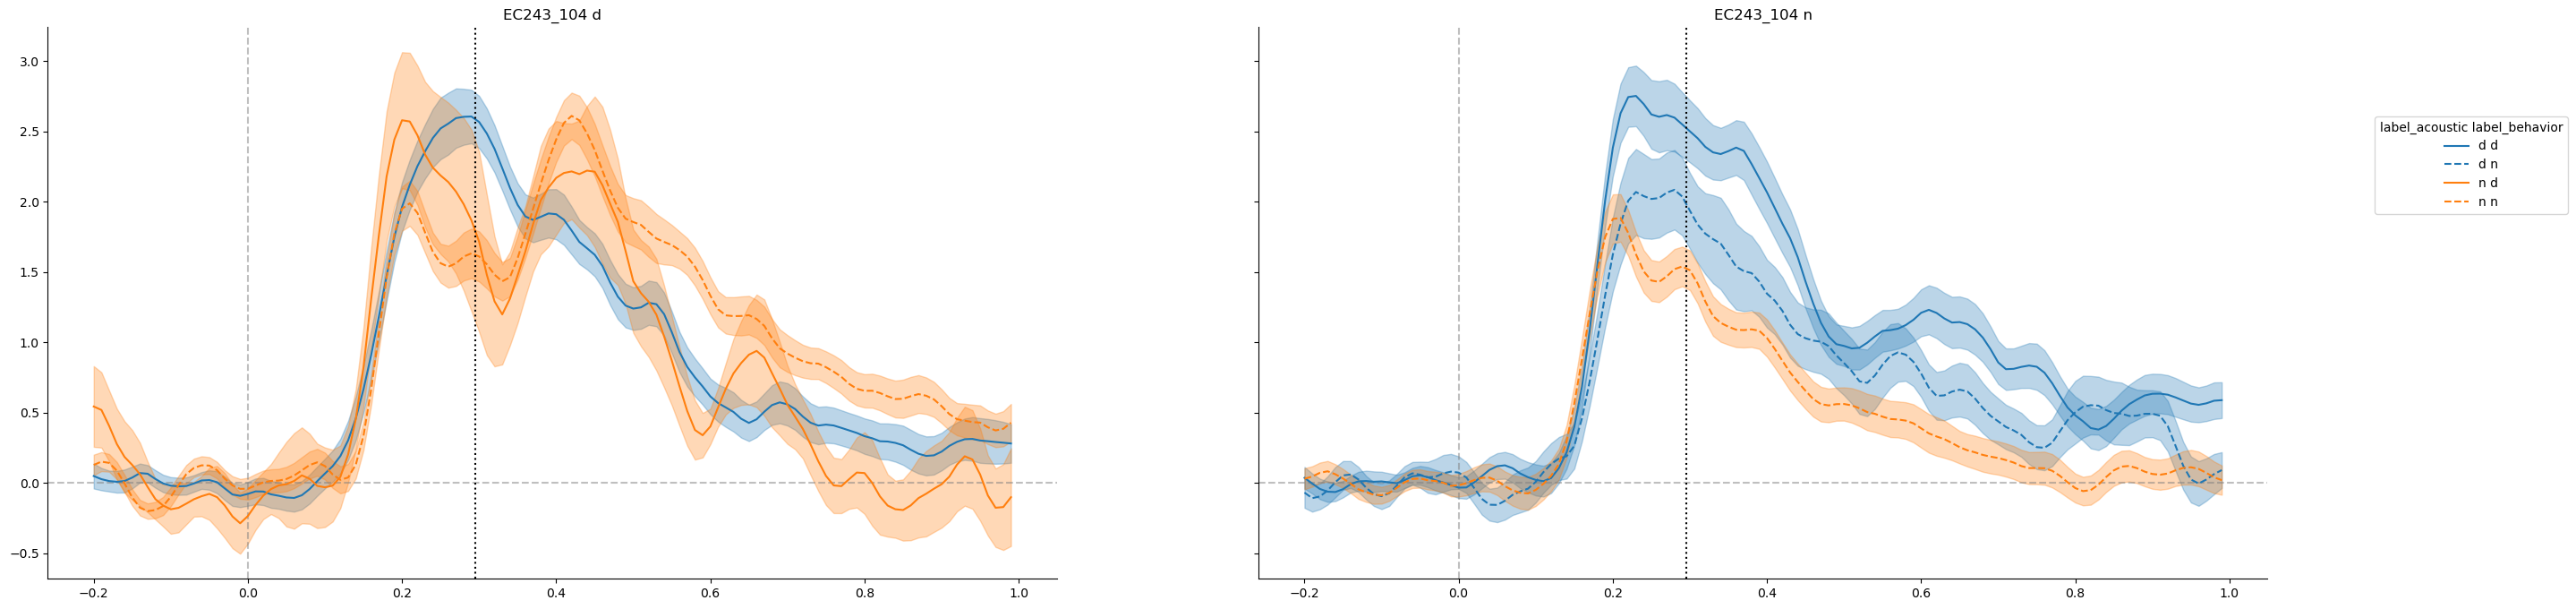

In [44]:
# # For debugging

feature_block = "acoustic"
suffix = "-baselined-continuous"
feature_block = "mismatch"
suffix = "-baselined-split"
kwargs = plot_specs[("eoi", feature_block)][suffix]

# ep, ep_df = make_epochs_df(feature_block, plot_eoi_df=eoi_df.loc[["EC278"]].loc[(slice(None), [121]), :],
#                            baseline=kwargs.get("baseline"))
ep, ep_df = make_epochs_df(feature_block, plot_eoi_df=eoi_df.loc[["EC243"]].loc[(slice(None), [103]), :],
                           baseline=kwargs.get("baseline"))

ep_df = ep_df[~ep_df.ignores_both_cues]
ep_df = ep_df[ep_df.phoneme_pair == "dn"]

# DEV
# kwargs["hue"] = "label_lexical_behavior"
# kwargs["style"] = "label_acoustic"
# kwargs["hue"] = "label"
# kwargs["style"] = "label_behavior"
kwargs["hue"] = "label_acoustic"
kwargs["col"] = "label_lexical"
kwargs["style"] = "label_behavior"
kwargs["share_groupers"] = True
# ep_df = ep_df.loc[ep_df.label_lexical_behavior.isin(("LdBd", "LdBn", "LnBn", "LnBd"))]
# kwargs["hue_order"] = ["LdBd", "LnBd", "LdBn", "LnBn"]
kwargs["height"] = 8
kwargs["drop_minority_traces"] = 5

plot_kwargs = {k: v for k, v in kwargs.items() if k not in ["baseline"]}
# plot_kwargs["smoke_test"] = True
# plot_kwargs["fix_ylim"] = "percentile"
# plot_kwargs["errorbar"] = None
g, p_ep, p_df = plot_epochs(ep, ep_df, epoch_times=epoch_times, **plot_kwargs)
# g = add_timit_insets(g, timit_epoch_sources)

In [51]:
def plot_mismatch_with_behavior(subject, elec, phoneme_pair):
    feature_block = "mismatch"
    suffix = "-baselined-split"
    kwargs = plot_specs[("eoi", feature_block)][suffix]

    # ep, ep_df = make_epochs_df(feature_block, plot_eoi_df=eoi_df.loc[["EC278"]].loc[(slice(None), [121]), :],
    #                            baseline=kwargs.get("baseline"))
    ep, ep_df = make_epochs_df(feature_block, plot_eoi_df=eoi_df.loc[[subject]].loc[(slice(None), [elec]), :],
                            baseline=kwargs.get("baseline"))

    # ep_df = ep_df[~ep_df.ignores_both_cues]
    ep_df = ep_df[ep_df.phoneme_pair == phoneme_pair]

    kwargs["col"] = "label_acoustic"
    kwargs["hue"] = "label_lexical"
    kwargs["style"] = "label_behavior"
    kwargs["share_groupers"] = True
    kwargs["height"] = 8
    kwargs["drop_minority_traces"] = 5

    plot_kwargs = {k: v for k, v in kwargs.items() if k not in ["baseline"]}
    g, p_ep, p_df = plot_epochs(ep, ep_df, epoch_times=epoch_times, **plot_kwargs)

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


yerp, no epochs for EC278 121 label_acoustic b ~
yerp, no epochs for EC278 121 label_acoustic m ~
yerp, no epochs for EC278 121 label_acoustic m ~


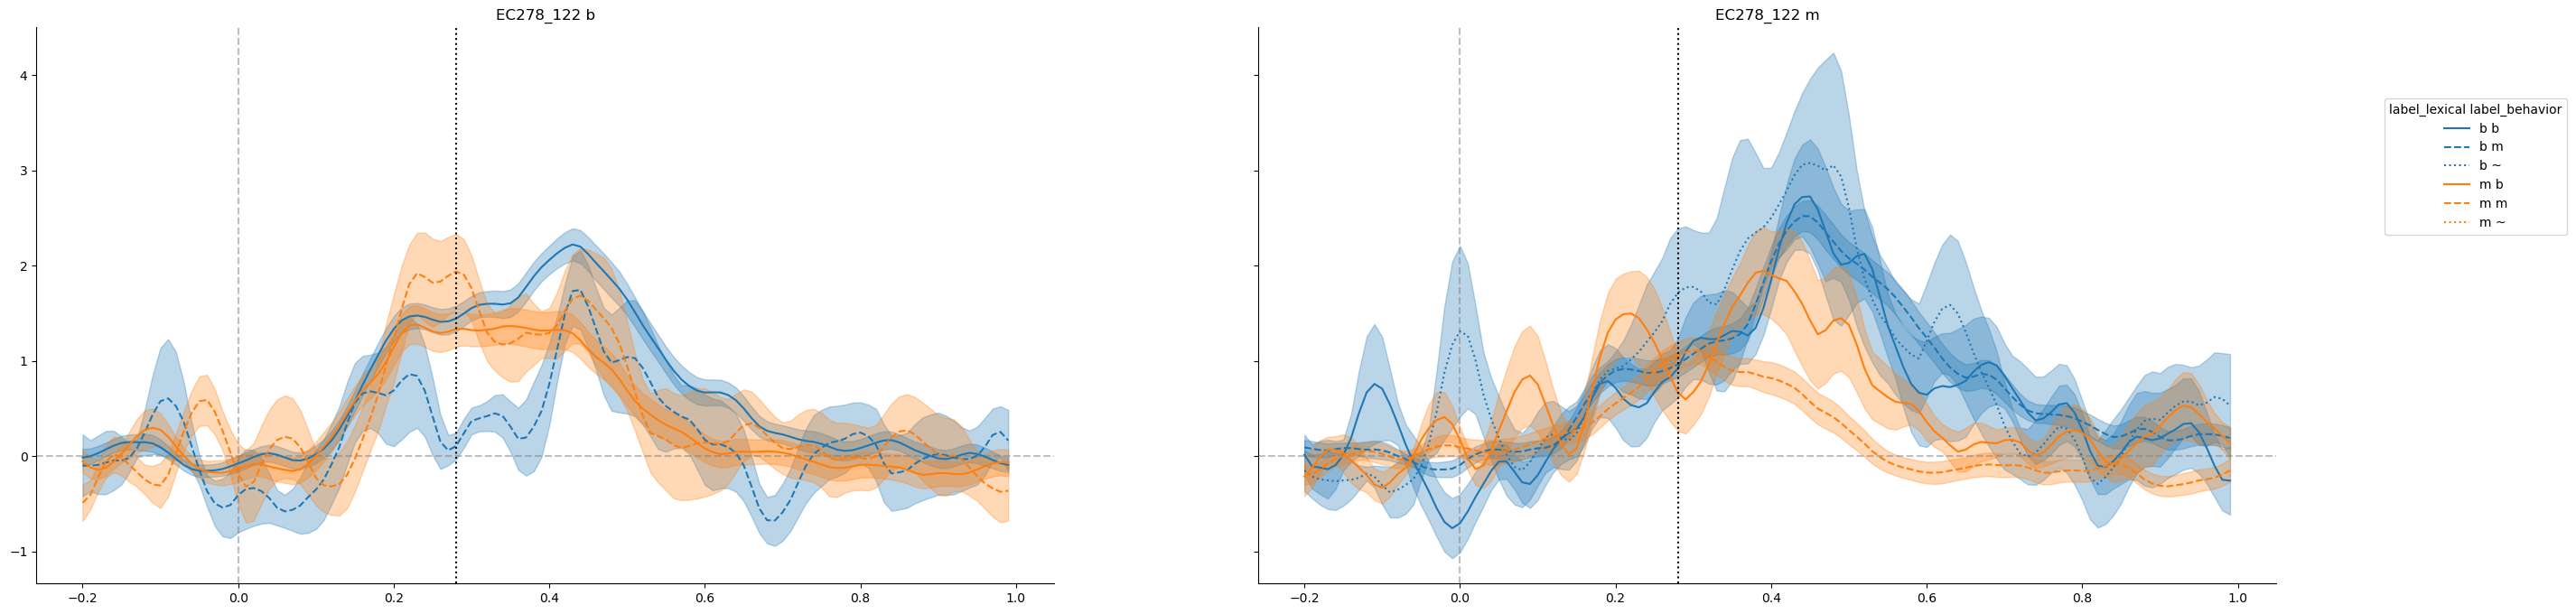

In [52]:
plot_mismatch_with_behavior("EC278", 121, "bm")

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


/scratch/jgauthier/transformers/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


yerp, no epochs for EC278 121 label_acoustic d n
yerp, no epochs for EC278 121 label_acoustic d ~
yerp, no epochs for EC278 121 label_acoustic n n
yerp, no epochs for EC278 121 label_acoustic n ~
yerp, no epochs for EC278 121 label_acoustic d ~
yerp, no epochs for EC278 121 label_acoustic n ~


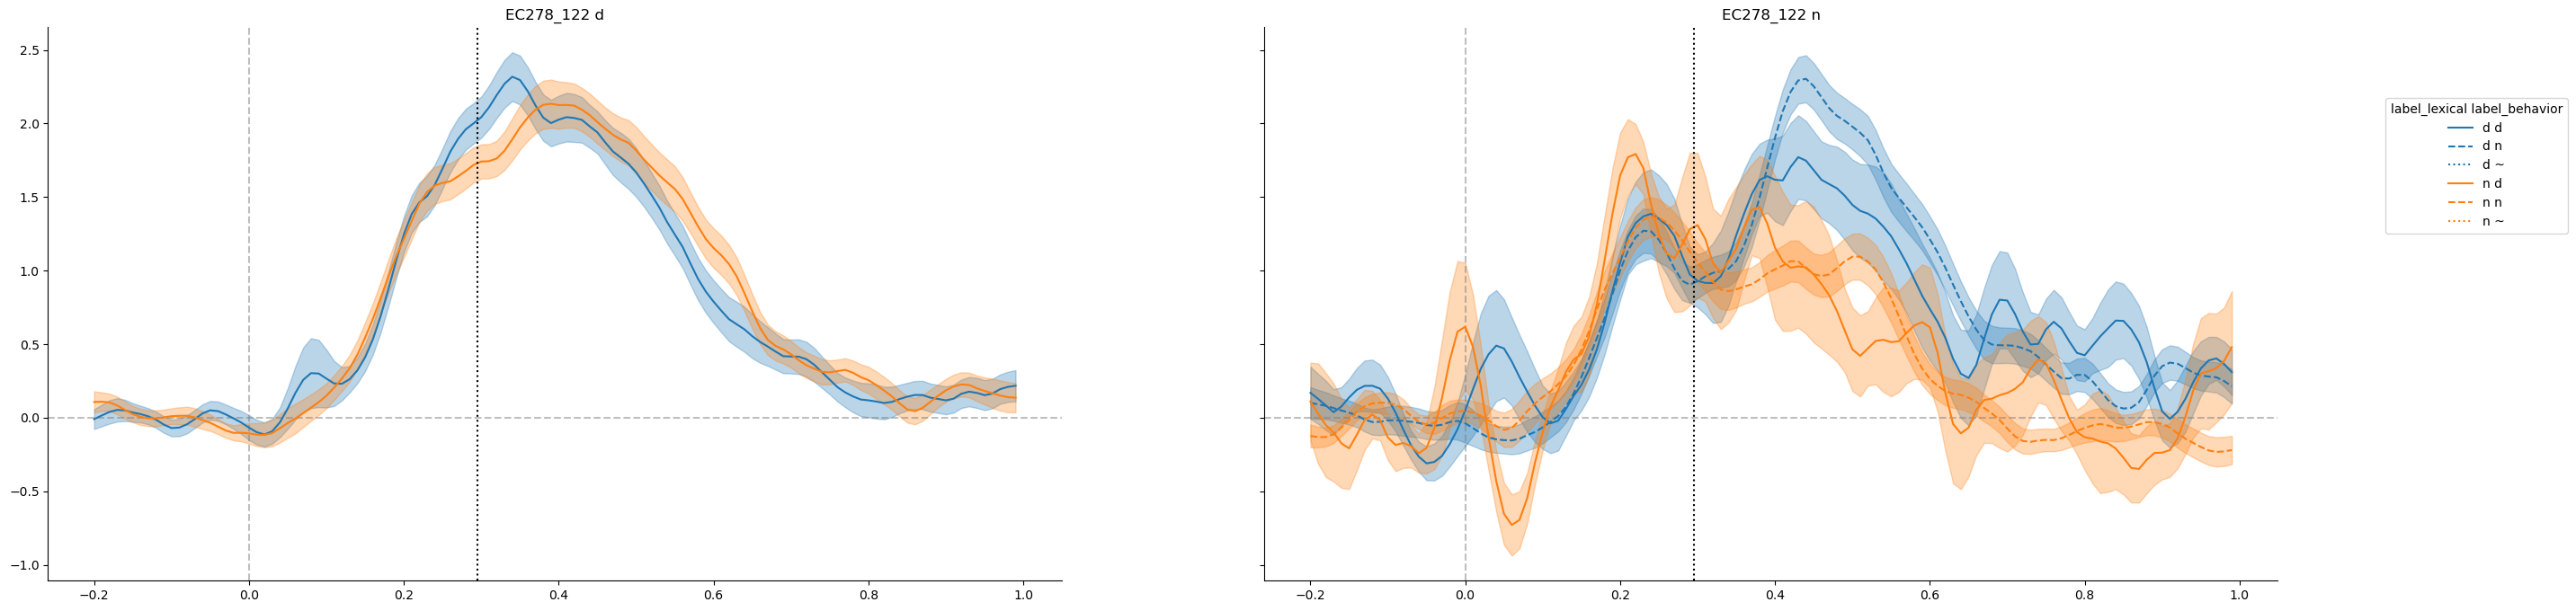

In [53]:
plot_mismatch_with_behavior("EC278", 121, "dn")

In [ ]:
for (eoi_source, feature_block), plot_spec in tqdm(plot_specs.items()):
    for suffix, kwargs in tqdm(plot_spec.items(), leave=False):
        make_kwarg_names = ["baseline"]

        make_kwargs = {k: v for k, v in kwargs.items() if k in make_kwarg_names}
        plot_kwargs = {k: v for k, v in kwargs.items() if k not in make_kwarg_names}

        if eoi_source == "eoi":
            plot_eoi_df = eoi_df
        elif eoi_source == "stepwise_eoi":
            plot_eoi_df = stepwise_eoi_df
        else:
            raise ValueError(f"Unknown eoi_source {eoi_source}")
        ep, ep_df = make_epochs_df(feature_block, plot_eoi_df=plot_eoi_df, **make_kwargs)

        g, p_ep, p_df = plot_epochs(ep, ep_df, close=False,
                                    epoch_times=epoch_times,
                                    **plot_kwargs)
        g = add_uv_annotation(g, feature_block, eoi_df)
        g = add_pod_line(g)
        g = add_timit_insets(g, timit_epoch_sources)
        g.savefig(f"{outdir}/epochs-{eoi_source}-{feature_block}{suffix}.pdf")
        plt.close(g.figure)